# Agent Backtesting Engine

**AI Trader Pro — Walk-Forward Backtesting with vectorbt**

Pipeline:
1. Load market data (yfinance)
2. Generate RSI signals
3. Backtest with vectorbt
4. Compute risk metrics
5. Walk-forward validation
6. Parameter optimization
7. Export figures to `research/figures/`

## 1. Setup

In [1]:
%matplotlib inline

from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
import seaborn as sns
import yfinance as yf

try:
    import vectorbt as vbt
except ImportError as exc:
    raise ImportError(
        'Install research deps: pip install -r research/requirements.txt'
    ) from exc

warnings.filterwarnings('ignore', category=FutureWarning)

plt.style.use('seaborn-v0_8-darkgrid')
FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TRADING_DAYS = 252
RISK_FREE_RATE = 0.04  # annual
SEED = 42
np.random.seed(SEED)

print(f'pandas {pd.__version__} | vectorbt {vbt.__version__}')

pandas 2.3.3 | vectorbt 1.0.0


## 2. Load Market Data

In [2]:
SYMBOL = 'SPY'
START = '2018-01-01'
END = '2024-12-31'

raw = yf.download(SYMBOL, start=START, end=END, auto_adjust=True, progress=False)
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

close = raw['Close'].dropna().astype(float)
returns = close.pct_change().dropna()

print(f'{SYMBOL}: {len(close)} bars | {close.index[0].date()} → {close.index[-1].date()}')
close.tail()

SPY: 1760 bars | 2018-01-02 → 2024-12-30


Date
2024-12-23    586.186707
2024-12-24    592.702148
2024-12-26    592.741577
2024-12-27    586.502014
2024-12-30    579.809204
Name: Close, dtype: float64

## 3. Strategy Signals (RSI Mean-Reversion)

In [3]:
def rsi_signals(close: pd.Series, window: int = 14, lower: float = 30, upper: float = 70) -> tuple[pd.Series, pd.Series]:
    rsi = vbt.RSI.run(close, window=window).rsi
    entries = rsi < lower
    exits = rsi > upper
    return entries.fillna(False), exits.fillna(False)

entries, exits = rsi_signals(close, window=14, lower=30, upper=70)
print(f'Entry signals: {int(entries.sum())} | Exit signals: {int(exits.sum())}')

Entry signals: 95 | Exit signals: 377


## 4. vectorbt Backtest

In [4]:
pf = vbt.Portfolio.from_signals(
    close,
    entries=entries,
    exits=exits,
    init_cash=100_000,
    fees=0.001,
    freq='1D',
)

equity = pf.value()
trade_returns = pf.trades.returns.values if pf.trades.count() else np.array([])
daily_returns = pf.returns().dropna()

summary = pf.stats()
print(summary[['Start', 'End', 'Total Return [%]', 'Max Drawdown [%]', 'Sharpe Ratio', 'Win Rate [%]', 'Total Trades']])

Start               2018-01-02 00:00:00
End                 2024-12-30 00:00:00
Total Return [%]              59.076103
Max Drawdown [%]              28.342546
Sharpe Ratio                   0.606367
Win Rate [%]                  78.947368
Total Trades                         19
dtype: object


## 5. Performance Metrics

In [5]:
def max_drawdown(equity_curve: pd.Series) -> float:
    peak = equity_curve.cummax()
    dd = (equity_curve - peak) / peak
    return float(dd.min())

def sharpe_ratio(daily_rets: pd.Series, rf: float = RISK_FREE_RATE) -> float:
    excess = daily_rets - rf / TRADING_DAYS
    if excess.std() == 0:
        return 0.0
    return float(np.sqrt(TRADING_DAYS) * excess.mean() / excess.std())

def sortino_ratio(daily_rets: pd.Series, rf: float = RISK_FREE_RATE) -> float:
    excess = daily_rets - rf / TRADING_DAYS
    downside = excess[excess < 0]
    if len(downside) == 0 or downside.std() == 0:
        return 0.0
    return float(np.sqrt(TRADING_DAYS) * excess.mean() / downside.std())

def profit_factor(trade_rets: np.ndarray) -> float:
    if trade_rets.size == 0:
        return 0.0
    gains = trade_rets[trade_rets > 0].sum()
    losses = abs(trade_rets[trade_rets < 0].sum())
    return float(gains / losses) if losses > 0 else float('inf')

def win_rate(trade_rets: np.ndarray) -> float:
    if trade_rets.size == 0:
        return 0.0
    return float((trade_rets > 0).mean())

def expectancy(trade_rets: np.ndarray) -> float:
    if trade_rets.size == 0:
        return 0.0
    return float(trade_rets.mean())

def calmar_ratio(daily_rets: pd.Series, equity_curve: pd.Series) -> float:
    ann_return = (1 + daily_rets.mean()) ** TRADING_DAYS - 1
    mdd = abs(max_drawdown(equity_curve))
    return float(ann_return / mdd) if mdd > 0 else 0.0

metrics = {
    'Sharpe': sharpe_ratio(daily_returns),
    'Sortino': sortino_ratio(daily_returns),
    'Calmar': calmar_ratio(daily_returns, equity),
    'Max Drawdown': max_drawdown(equity),
    'Profit Factor': profit_factor(trade_returns),
    'Win Rate': win_rate(trade_returns),
    'Expectancy': expectancy(trade_returns),
    'Total Return': float(equity.iloc[-1] / equity.iloc[0] - 1),
    'Trades': int(pf.trades.count()),
}

metrics_df = pd.DataFrame([metrics]).T
metrics_df.columns = ['Value']
metrics_df.style.format('{:.4f}')

,Value
Sharpe,0.2479
Sortino,0.3309
Calmar,0.2890
Max Drawdown,-0.2834
Profit Factor,2.7956
Win Rate,0.7895
Expectancy,0.0263
Total Return,0.5908
Trades,19.0000


## 6. Walk-Forward Optimization

In [6]:
def walk_forward_backtest(
    close: pd.Series,
    train_bars: int = 504,
    test_bars: int = 126,
    window: int = 14,
    lower: float = 30,
    upper: float = 70,
) -> pd.DataFrame:
    rows = []
    start = 0
    fold = 0
    while start + train_bars + test_bars <= len(close):
        train_slice = close.iloc[start : start + train_bars]
        test_slice = close.iloc[start + train_bars : start + train_bars + test_bars]
        ent, ex = rsi_signals(test_slice, window=window, lower=lower, upper=upper)
        fold_pf = vbt.Portfolio.from_signals(
            test_slice, entries=ent, exits=ex, init_cash=100_000, fees=0.001, freq='1D'
        )
        fold_eq = fold_pf.value()
        fold_rets = fold_pf.returns().dropna()
        fold_trades = fold_pf.trades.returns.values if fold_pf.trades.count() else np.array([])
        rows.append(
            {
                'fold': fold,
                'test_start': test_slice.index[0].date(),
                'test_end': test_slice.index[-1].date(),
                'total_return': float(fold_eq.iloc[-1] / fold_eq.iloc[0] - 1),
                'sharpe': sharpe_ratio(fold_rets),
                'max_drawdown': max_drawdown(fold_eq),
                'win_rate': win_rate(fold_trades),
                'trades': int(fold_pf.trades.count()),
            }
        )
        start += test_bars
        fold += 1
    return pd.DataFrame(rows)

wf_results = walk_forward_backtest(close)
print(f'Walk-forward folds: {len(wf_results)}')
wf_results

Walk-forward folds: 9


,fold,test_start,test_end,total_return,sharpe,max_drawdown,win_rate,trades
0,0,2020-01-03,2020-07-02,-0.106743,-4.710726e-01,-0.283425,0.0,1
1,1,2020-07-06,2020-12-31,0.193678,3.625837e+00,-0.014216,1.0,2
2,2,2021-01-04,2021-07-02,0.000000,-9.259322e+16,0.000000,0.0,0
3,3,2021-07-06,2021-12-31,0.040241,6.757089e-01,-0.034399,1.0,1
4,4,2022-01-03,2022-07-05,-0.073191,-7.039826e-01,-0.147584,0.5,2
5,5,2022-07-06,2023-01-03,0.020192,9.266308e-02,-0.128830,0.5,2
6,6,2023-01-04,2023-07-06,0.035005,4.148724e-01,-0.047247,1.0,1
7,7,2023-07-07,2024-01-04,0.069455,1.093944e+00,-0.058764,1.0,2
8,8,2024-01-05,2024-07-08,0.037120,7.392602e-01,-0.019037,1.0,1


## 7. Parameter Optimization (Grid Search)

In [7]:
def optimize_rsi_params(
    close: pd.Series,
    windows: list[int] | None = None,
    lowers: list[float] | None = None,
    uppers: list[float] | None = None,
) -> pd.DataFrame:
    windows = windows or [10, 14, 20, 28]
    lowers = lowers or [25, 30, 35]
    uppers = uppers or [65, 70, 75]
    rows = []
    for w in windows:
        for lo in lowers:
            for hi in uppers:
                if lo >= hi:
                    continue
                ent, ex = rsi_signals(close, window=w, lower=lo, upper=hi)
                opt_pf = vbt.Portfolio.from_signals(
                    close, entries=ent, exits=ex, init_cash=100_000, fees=0.001, freq='1D'
                )
                opt_eq = opt_pf.value()
                opt_rets = opt_pf.returns().dropna()
                opt_trades = opt_pf.trades.returns.values if opt_pf.trades.count() else np.array([])
                rows.append(
                    {
                        'window': w,
                        'lower': lo,
                        'upper': hi,
                        'sharpe': sharpe_ratio(opt_rets),
                        'sortino': sortino_ratio(opt_rets),
                        'max_drawdown': max_drawdown(opt_eq),
                        'total_return': float(opt_eq.iloc[-1] / opt_eq.iloc[0] - 1),
                        'win_rate': win_rate(opt_trades),
                        'profit_factor': profit_factor(opt_trades),
                        'trades': int(opt_pf.trades.count()),
                    }
                )
    return pd.DataFrame(rows).sort_values('sharpe', ascending=False)

param_grid = optimize_rsi_params(close.iloc[-756:])  # last ~3 years for speed
best = param_grid.iloc[0]
print('Best params (by Sharpe):')
print(best[['window', 'lower', 'upper', 'sharpe', 'total_return', 'max_drawdown', 'trades']])
param_grid.head(10)

Best params (by Sharpe):
window          10.000000
lower           25.000000
upper           70.000000
sharpe           0.616879
total_return     0.389485
max_drawdown    -0.128830
trades          14.000000
Name: 1, dtype: float64


,window,lower,upper,sharpe,sortino,max_drawdown,total_return,win_rate,profit_factor,trades
1,10,25,70,0.616879,0.878544,-0.128830,0.389485,0.857143,4.739888,14
24,20,35,65,0.464877,0.667731,-0.165396,0.320908,0.875000,6.258555,8
2,10,25,75,0.430543,0.604329,-0.128830,0.301489,0.666667,3.398415,12
7,10,35,70,0.402841,0.556774,-0.128830,0.290309,0.764706,2.971666,17
9,14,25,65,0.374577,0.537036,-0.128830,0.260894,0.777778,11.001973,9
12,14,30,65,0.363837,0.513316,-0.128830,0.260689,0.700000,6.550744,10
14,14,30,75,0.363370,0.511919,-0.145458,0.278447,0.750000,11.082697,8
32,28,30,75,0.362452,0.559478,-0.099743,0.243641,1.000000,inf,1
25,20,35,70,0.357685,0.506687,-0.205611,0.273303,0.857143,6.658615,7
11,14,25,75,0.345170,0.492564,-0.145458,0.264899,0.714286,133.035106,7


## 8. Visualizations

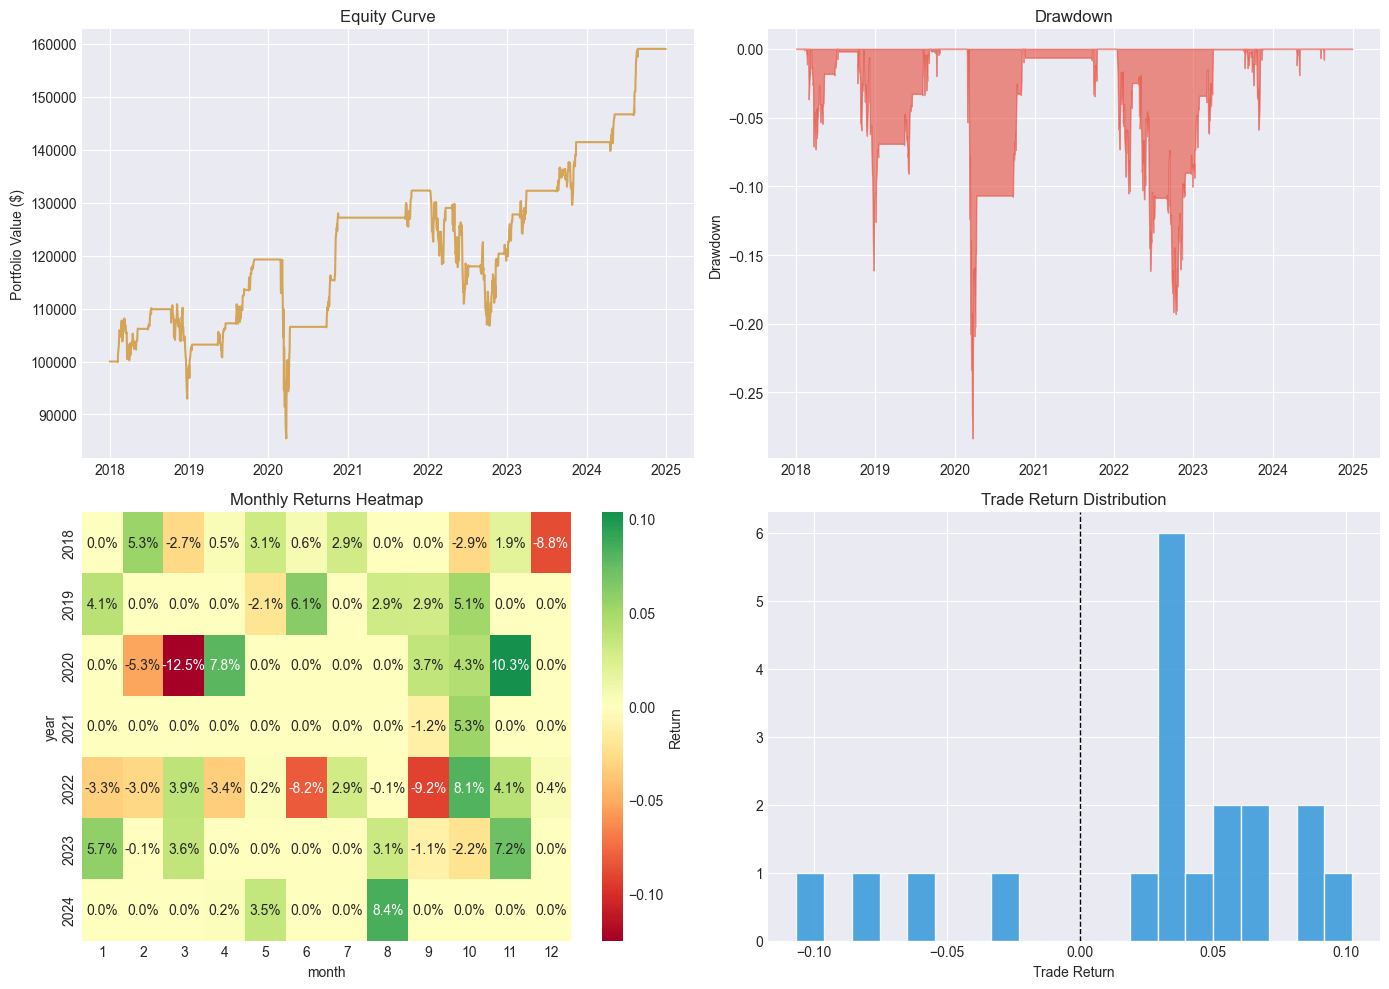

Saved figures/backtest_equity_drawdown.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Equity curve
axes[0, 0].plot(equity.index, equity.values, color='#d4a458', linewidth=1.5)
axes[0, 0].set_title('Equity Curve')
axes[0, 0].set_ylabel('Portfolio Value ($)')

# Drawdown
peak = equity.cummax()
dd = (equity - peak) / peak
axes[0, 1].fill_between(dd.index, dd.values, 0, color='#e74c3c', alpha=0.6)
axes[0, 1].set_title('Drawdown')
axes[0, 1].set_ylabel('Drawdown')

# Monthly returns heatmap
monthly = daily_returns.resample('ME').apply(lambda x: (1 + x).prod() - 1)
monthly_df = monthly.to_frame('return')
monthly_df['year'] = monthly_df.index.year
monthly_df['month'] = monthly_df.index.month
pivot = monthly_df.pivot(index='year', columns='month', values='return')
sns.heatmap(pivot, annot=True, fmt='.1%', cmap='RdYlGn', center=0, ax=axes[1, 0], cbar_kws={'label': 'Return'})
axes[1, 0].set_title('Monthly Returns Heatmap')

# Trade return distribution
if trade_returns.size:
    axes[1, 1].hist(trade_returns, bins=20, color='#3498db', edgecolor='white', alpha=0.85)
    axes[1, 1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1, 1].set_title('Trade Return Distribution')
axes[1, 1].set_xlabel('Trade Return')

plt.tight_layout()
equity_path = FIGURES_DIR / 'backtest_equity_drawdown.png'
plt.savefig(equity_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {equity_path}')

In [9]:
# Parameter optimization surface (Sharpe vs RSI window & lower threshold)
surface = param_grid.pivot_table(index='lower', columns='window', values='sharpe', aggfunc='mean')
fig = px.imshow(
    surface,
    labels=dict(x='RSI Window', y='Lower Threshold', color='Sharpe'),
    title='Parameter Optimization — Sharpe Ratio Surface',
    color_continuous_scale='Viridis',
    aspect='auto',
)
surface_path = FIGURES_DIR / 'backtest_param_surface.html'
fig.write_html(surface_path)
fig.show()
print(f'Saved {surface_path}')

Saved figures/backtest_param_surface.html


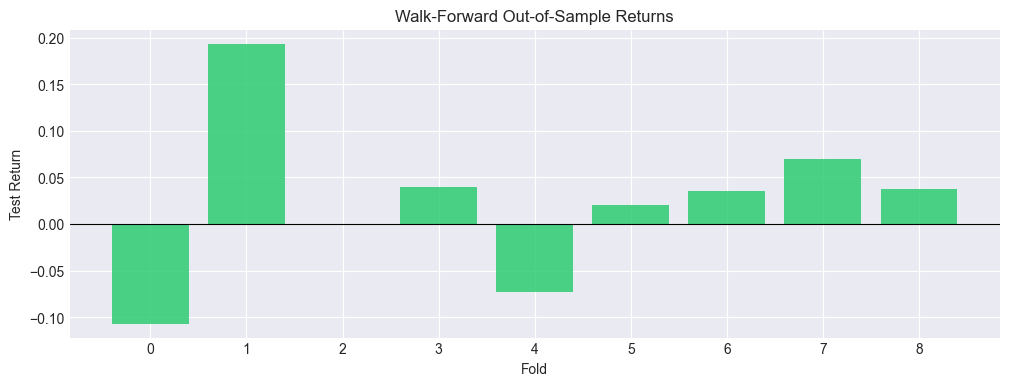

Saved figures/backtest_walk_forward.png


In [10]:
# Walk-forward fold performance
if not wf_results.empty:
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(wf_results['fold'].astype(str), wf_results['total_return'], color='#2ecc71', alpha=0.85)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Fold')
    ax.set_ylabel('Test Return')
    ax.set_title('Walk-Forward Out-of-Sample Returns')
    wf_path = FIGURES_DIR / 'backtest_walk_forward.png'
    plt.savefig(wf_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved {wf_path}')

## 9. Summary

In [11]:
print('=' * 60)
print('BACKTEST SUMMARY')
print('=' * 60)
for k, v in metrics.items():
    if isinstance(v, float):
        print(f'  {k:18s}: {v:>10.4f}')
    else:
        print(f'  {k:18s}: {v:>10}')
if not wf_results.empty:
    print(f"\nWalk-forward avg Sharpe : {wf_results['sharpe'].mean():.4f}")
    print(f"Walk-forward avg return: {wf_results['total_return'].mean():.2%}")
print(f"\nBest RSI params       : window={int(best['window'])}, lower={int(best['lower'])}, upper={int(best['upper'])}")
print(f"Best in-sample Sharpe  : {best['sharpe']:.4f}")

BACKTEST SUMMARY
  Sharpe            :     0.2479
  Sortino           :     0.3309
  Calmar            :     0.2890
  Max Drawdown      :    -0.2834
  Profit Factor     :     2.7956
  Win Rate          :     0.7895
  Expectancy        :     0.0263
  Total Return      :     0.5908
  Trades            :         19

Walk-forward avg Sharpe : -10288135218189626.0000
Walk-forward avg return: 2.40%

Best RSI params       : window=10, lower=25, upper=70
Best in-sample Sharpe  : 0.6169
